In [26]:
import pandas as pd, numpy as np, joblib
from sklearn.model_selection import (
    train_test_split, KFold, cross_validate,
    GridSearchCV)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso)
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor)
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error, r2_score)

In [27]:
from google.cloud import bigquery
from dotenv import load_dotenv
import datetime

# 1. Authentification locale (remplace auth.authenticate_user() de Colab)
# Cela va chercher automatiquement la variable GOOGLE_APPLICATION_CREDENTIALS dans votre fichier .env
load_dotenv()

PROJET = "les-fourcasters"
DATASET = "dbt_dev_marts"

# 2. Initialisation du client
client = bigquery.Client(project=PROJET)
print("Client prêt sur", client.project)

# 3. Récupération des données dans un DataFrame pandas
annee_en_cours=datetime.date.today().year # Année à prédire

canicules_features = client.query(f"SELECT * FROM `{PROJET}.{DATASET}.canicule_features`").to_dataframe()
canicules_features=canicules_features[canicules_features['annee_reference_canicule']<annee_en_cours]
print(f"""✅ Données chargées avec succès ! Dimensions du dataset : {canicules_features.shape}.
Années non pris en compte : {annee_en_cours} et au delà""")

Client prêt sur les-fourcasters
✅ Données chargées avec succès ! Dimensions du dataset : (2112, 16).
Années non pris en compte : 2026 et au delà


In [28]:
canicules_features.sample(5)

,code_departement,annee_reference_canicule,t_moy_automne,precip_automne,t_moy_hiver,precip_hiver,t_moy_printemps,precip_printemps,humidite_printemps,part_jours_secs_printemps,t_max_mai,part_jours_chauds_mai,nb_jour_canicules,evenement_caniculaire,population_exposee,severite
1796,40,2016,15.070330,1.580952,9.285714,3.786081,12.150725,2.742391,74.365942,0.510870,20.565591,0.086022,4.0,True,405010.0,10.1
2280,39,2020,13.283516,4.005861,6.309158,4.306593,12.785870,2.569928,67.536232,0.760870,20.536559,0.075269,17.0,True,258798.0,42.2
419,34,2007,16.390110,5.219414,7.956296,1.337407,13.587319,2.583696,72.887681,0.713768,20.329032,0.139785,0.0,False,0.0,0.0
951,86,2013,13.232234,3.010989,5.283704,2.690370,9.506884,2.693841,76.601449,0.586957,15.612903,0.000000,0.0,False,0.0,0.0
460,78,2007,14.113846,1.790769,6.736222,1.924667,11.936087,1.559565,75.067391,0.619565,18.774194,0.012903,0.0,False,0.0,0.0


In [29]:
CIBLE   = "nb_jour_canicules"
A_JETER = [
    'evenement_caniculaire', 
    'population_exposee',
    'severite'
    ]

print(canicules_features.shape, "| doublons :", canicules_features.duplicated().sum())
print(canicules_features.isna().mean().mul(100).round(1)[lambda s: s > 0])
print(canicules_features.describe())     # cherche les min/max absurdes
print(canicules_features.corr(numeric_only=True)[CIBLE].sort_values())

(2112, 16) | doublons : 0
Series([], dtype: float64)
       annee_reference_canicule  t_moy_automne  precip_automne  t_moy_hiver  \
count                    2112.0    2112.000000     2112.000000  2112.000000   
mean                     2014.5      13.120487        2.565164     5.035569   
std                    6.345791       1.807783        1.006444     2.133831   
min                      2004.0       6.645421        0.448132    -4.311111   
25%                      2009.0      11.953571        1.822985     3.668704   
50%                      2014.5      13.007875        2.435385     5.159421   
75%                      2020.0      14.256941        3.127473     6.542343   
max                      2025.0      19.224908        8.270696    11.246886   

       precip_hiver  t_moy_printemps  precip_printemps  humidite_printemps  \
count   2112.000000      2112.000000       2112.000000         2112.000000   
mean       2.531965        11.142754          2.462782           74.075501   
s

In [30]:
X = canicules_features.drop(columns=[CIBLE] + A_JETER)
y = canicules_features[CIBLE]

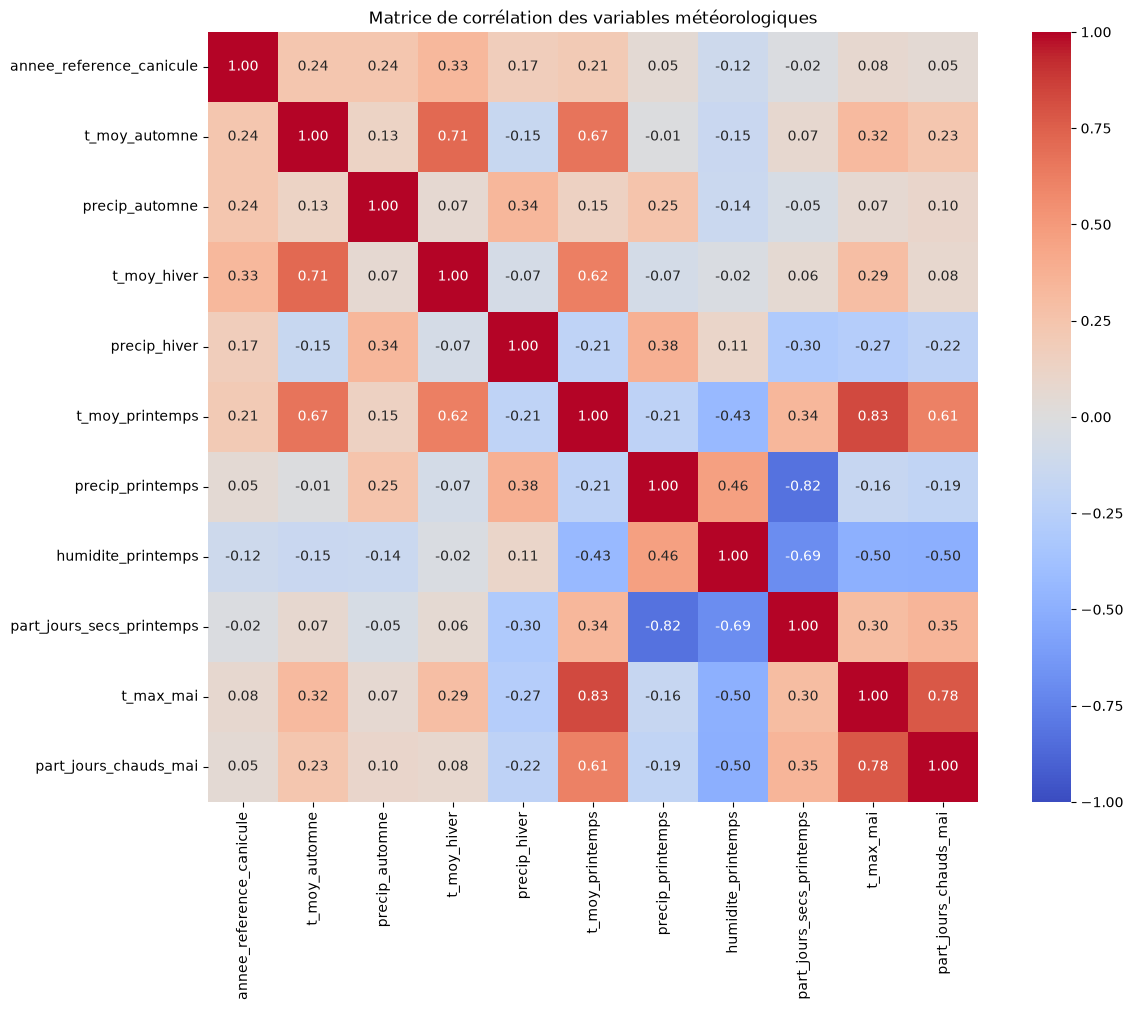

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcul de la matrice sur vos features d'entraînement (X)
matrice_corr = X.corr(numeric_only=True)

# 2. Configuration visuelle de la carte de chaleur
plt.figure(figsize=(14, 10))
sns.heatmap(
    matrice_corr, 
    annot=True,        # Affiche les scores de corrélation
    fmt=".2f",         # Limite à 2 décimales pour la lisibilité
    cmap="coolwarm",   # Dégradé : rouge (corrélation positive), bleu (négative)
    vmin=-1, vmax=1,   # Borne l'échelle mathématique
    center=0,
    square=True
)
plt.title("Matrice de corrélation des variables météorologiques")
plt.show()

In [32]:
print(y.skew())          # > 1 : pense au log

2.3469228779156976


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
base = DummyRegressor(strategy="mean")
base = base.fit(X_train, y_train)
print("baseline MAE :",mean_absolute_error(y_test, base.predict(X_test)))

baseline MAE : 2.822350713208957


In [35]:
# ---- 5. Preparation : une branche par type ----
num = X.select_dtypes(include=np.number).columns.tolist()
cat = X.select_dtypes(exclude=np.number).columns.tolist()

branche_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())])
branche_cat = Pipeline([
    ("imputer", 
    SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

prep = ColumnTransformer([("num", branche_num, num), ("cat", branche_cat, cat)])

In [36]:
# ---- 6. Comparer en validation croisee --------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rs = dict(random_state=42)
modeles = {
  "Linear": LinearRegression(),
  "Ridge":  Ridge(alpha=1.0),
  "Lasso":  Lasso(alpha=1.0),
  "Foret":  RandomForestRegressor(n_jobs=-1, **rs),
  "HistGB": HistGradientBoostingRegressor(**rs),
}
# for nom, m in modeles.items():
#   tube = Pipeline([("prep", prep), ("modele", m)])
#   r = cross_validate(tube, X_train, y_train, cv=cv,
#         scoring=["neg_mean_absolute_error", "r2"],
#         return_train_score=True)
#   print(nom,
#         -r["test_neg_mean_absolute_error"].mean(),
#         r["test_r2"].mean(), 
#         r["test_r2"].std(),
#         r["train_r2"].mean()
#         )

# 1. On crée un en-tête de tableau avant la boucle pour s'y retrouver
print(f"{'Modèle':<10} | {'MAE Test':<10} | {'R² Test':<10} | {'Std R²':<10} | {'R² Train':<10}")
print("-" * 60)

for nom, m in modeles.items():
    tube = Pipeline([("prep", prep), ("modele", m)])
    r = cross_validate(tube, X_train, y_train, cv=cv, scoring=["neg_mean_absolute_error", "r2"], return_train_score=True)
    
    # 2. On stocke les résultats pour alléger la ligne de print
    mae = -r["test_neg_mean_absolute_error"].mean()
    r2_test = r["test_r2"].mean()
    r2_std = r["test_r2"].std()
    r2_train = r["train_r2"].mean()
    
    # 3. L'affichage magique : 
    # <10 aligne le texte à gauche sur 10 caractères
    # .3f force l'affichage à 3 chiffres après la virgule
    print(f"{nom:<10} | {mae:<10.3f} | {r2_test:<10.3f} | {r2_std:<10.3f} | {r2_train:<10.3f}")

Modèle     | MAE Test   | R² Test    | Std R²     | R² Train  
------------------------------------------------------------
Linear     | 2.426      | 0.279      | 0.046      | 0.398     
Ridge      | 2.411      | 0.286      | 0.044      | 0.396     
Lasso      | 2.836      | 0.055      | 0.015      | 0.062     
Foret      | 1.798      | 0.449      | 0.050      | 0.924     
HistGB     | 1.926      | 0.415      | 0.045      | 0.901     


In [37]:
# ---- 7. Regler le gagnant ---------------------
modele = HistGradientBoostingRegressor(loss="poisson", **rs)
tube = Pipeline([("prep", prep), ("modele", modele)])
grille = {
    "modele__max_iter": [100, 200],
    "modele__learning_rate": [0.01, 0.8],
    # Nouveaux paramètres de régularisation :
    "modele__max_depth": [3, 5, 7],           # Empêche les arbres d'aller trop en profondeur (par défaut : aucune limite)
    "modele__min_samples_leaf": [20, 50],     # Force un nombre minimum d'exemples par "feuille" pour éviter le par-coeur
    "modele__l2_regularization": [0.0, 0.5, 1.0], # Pénalise les poids trop importants
    "prep__num__imputer__strategy":["median", "mean"]
}
gs = GridSearchCV(tube, grille, cv=cv, n_jobs=-1, scoring="neg_mean_absolute_error")
gs = gs.fit(X_train, y_train)
print(gs.best_params_, round(-gs.best_score_, 2))

{'modele__l2_regularization': 0.5, 'modele__learning_rate': 0.01, 'modele__max_depth': 7, 'modele__max_iter': 200, 'modele__min_samples_leaf': 20, 'prep__num__imputer__strategy': 'median'} 1.95


In [38]:
# ---- 8. Le test, UNE SEULE FOIS ---------------
final = gs.best_estimator_
p = final.predict(X_test)
print(f"""
MAE {mean_absolute_error(y_test, p):.1f} 
RMSE {root_mean_squared_error(y_test, p):.1f} 
R2 {r2_score(y_test, p):.3f}""")
print(f"""
train R2 {round(final.score(X_train, y_train),3)}
test R2 {round(final.score(X_test, y_test),3)}
""")
print("prediction min :", p.min())   # possible ?

# ---- 9. Livrer --------------------------------
joblib.dump(final, "modele_canicule_nb_jour.joblib")


MAE 1.8 
RMSE 2.7 
R2 0.446

train R2 0.661
test R2 0.446

prediction min : 0.36162907857793036


['modele_canicule_nb_jour.joblib']